# Домашняя работа №12

## Импорты, seed и среда

In [1]:
import math
import random
import torch
import torch.nn as nn
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [2]:
ART_DIR = 'artifacts/'
FIG_DIR = ART_DIR + 'figures/'
os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)


In [3]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Device:", device)

Device: mps


## Загрузка данных

In [5]:
df = pd.read_csv('S12-hw-dataset.csv')
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [6]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    4320 non-null   datetime64[ns]
 1   target  4320 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 67.6 KB


In [7]:
print("Строк:", len(df))
print("Диапазон дат:", df["date"].min().date(), "→", df["date"].max().date())
print("\nПропуски:")
print(df.isnull().sum())

Строк: 4320
Диапазон дат: 2025-01-01 → 2025-06-29

Пропуски:
date      0
target    0
dtype: int64


Пропусков в данных нет

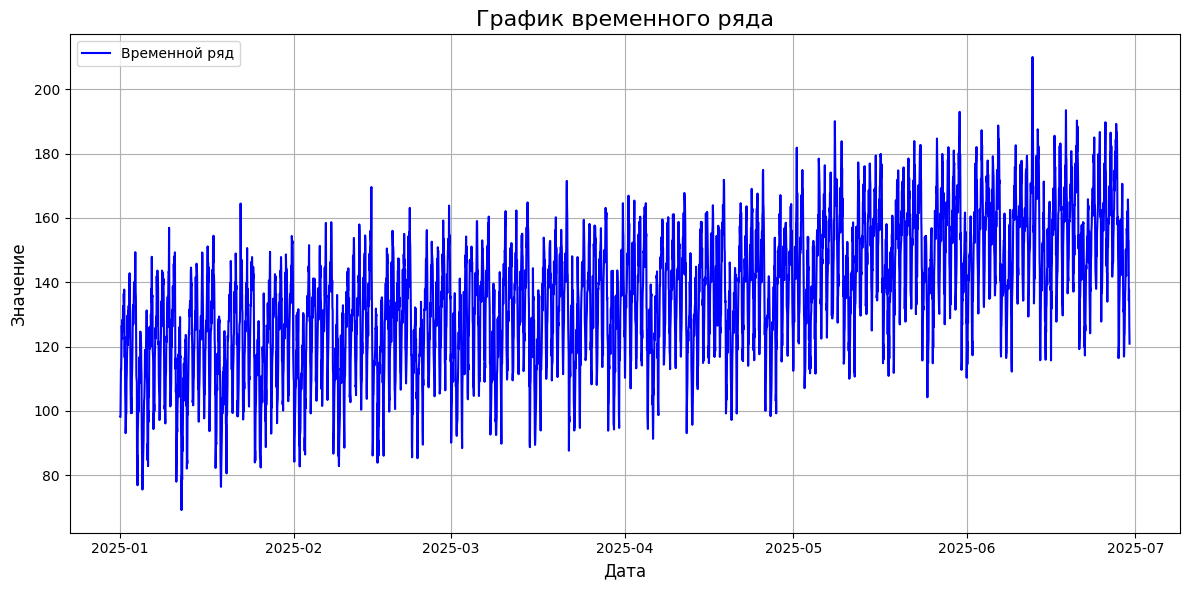

In [8]:
plt.figure(figsize=(12, 6)) # Размер графика
plt.plot(df['date'], df['target'], label='Временной ряд', color='blue', linewidth=1.5)

plt.title('График временного ряда', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.legend()
plt.tight_layout()

plt.show()


In [9]:
df['date'].max(), df['date'].min()

(Timestamp('2025-06-29 23:00:00'), Timestamp('2025-01-01 00:00:00'))

## Разбиение данных

train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


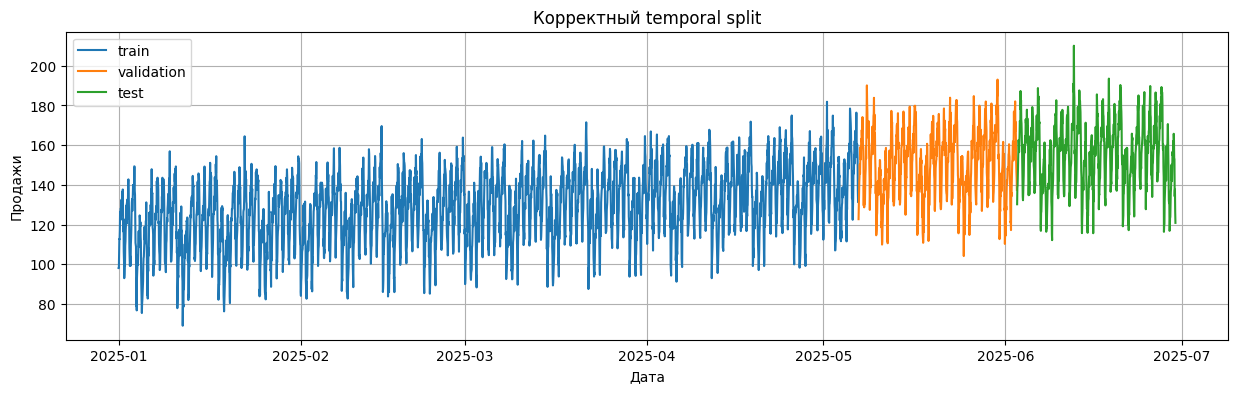

In [10]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    # Проверяем, что доли действительно покрывают весь датасет.
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    # Ключевая идея: train, validation и test идут по времени друг за другом.
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректный temporal split")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.show()

При случайном перемешивании модель видит в обучении данные из периодов, которые хронологически позже тест-выборки. Это приводит к утечке информации из будущего в прошлое (data leakage), и реальные метрики на продакшн-данных окажутся значительно хуже валидационных.

При случайном перемешивании модель видит в обучении данные из периодов,
которые хронологически позже тест-выборки. Это приводит к утечке информации
из будущего в прошлое (data leakage), и реальные метрики на продакшн-данных
окажутся значительно хуже валидационных.

В данной работе устранены все основные источники утечки:
- **Лаги и rolling**: `.shift(1)` перед любой агрегацией — текущее значение не попадает в признак
- **Масштабирование**: `scaler.fit()` только на `train`, `transform` на val/test отдельно
- **Выбор модели**: лучшая модель определяется по `validation`, `test` используется один раз

## Признаки для baseline-моделей

In [11]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month

    # Синус/косинус кодируют цикличность без искусственного разрыва между концом и началом периода.
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()
    
    for lag in [1, 2, 3, 5, 7, 10, 14, 21, 28, 35, 42]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)
    
    for w in [3, 7, 14, 28]:
        s = out[target_col].shift(1)
        out[f"rolling_mean_{w}"]  = s.rolling(w).mean()
        out[f"rolling_std_{w}"]   = s.rolling(w).std()
        out[f"rolling_max_{w}"]   = s.rolling(w).max()
        out[f"rolling_min_{w}"]   = s.rolling(w).min()
        out[f"rolling_range_{w}"] = out[f"rolling_max_{w}"] - out[f"rolling_min_{w}"]

    # EWM (экспоненциальное сглаживание) - отдаёт больший вес свежим данным
    for alpha in [0.3, 0.1]:
        out[f"ewm_{int(alpha*10)}"] = out[target_col].shift(1).ewm(alpha=alpha).mean()

    # Разности (первая и сезонная) — помогают при нестационарном ряде
    out["diff_1"]  = out[target_col].shift(1).diff(1)
    out["diff_7"]  = out[target_col].shift(1).diff(7)
    out["diff_28"] = out[target_col].shift(1).diff(28)

    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()

,date,target,dayofweek,month,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_5,lag_7,lag_10,lag_14,lag_21,lag_28,lag_35,lag_42,rolling_mean_3,rolling_std_3,rolling_max_3,rolling_min_3,rolling_range_3,rolling_mean_7,rolling_std_7,rolling_max_7,rolling_min_7,rolling_range_7,rolling_mean_14,rolling_std_14,rolling_max_14,rolling_min_14,rolling_range_14,rolling_mean_28,rolling_std_28,rolling_max_28,rolling_min_28,rolling_range_28,ewm_3,ewm_1,diff_1,diff_7,diff_28
0,2025-01-02 18:00:00,130.48,3,1,0.433884,-0.900969,0.5,0.866025,137.18,142.80,140.38,125.00,122.76,124.85,111.64,106.54,128.87,126.01,98.14,140.120000,2.819007,142.80,137.18,5.62,133.118571,7.534964,142.8,122.76,20.04,127.610714,8.992419,142.8,111.64,31.16,121.176429,14.390252,142.8,93.04,49.76,135.446374,126.539289,-5.62,6.13,12.14
1,2025-01-02 19:00:00,122.34,3,1,0.433884,-0.900969,0.5,0.866025,130.48,137.18,142.80,131.05,132.66,120.48,117.30,101.72,136.40,122.38,98.07,136.820000,6.167885,142.80,130.48,12.32,134.221429,6.215600,142.8,125.00,17.80,128.956429,7.741211,142.8,117.30,25.50,121.233929,14.425306,142.8,93.04,49.76,133.956462,126.937652,-6.70,7.72,1.61
2,2025-01-02 20:00:00,108.30,3,1,0.433884,-0.900969,0.5,0.866025,122.34,130.48,137.18,140.38,125.00,131.05,119.72,93.04,133.85,128.28,104.70,130.000000,7.431635,137.18,122.34,14.84,132.747143,7.695429,142.8,122.34,20.46,129.316429,7.259651,142.8,119.72,23.08,120.731786,14.119292,142.8,93.04,49.76,130.471523,126.473385,-8.14,-10.32,-14.06
3,2025-01-02 21:00:00,104.26,3,1,0.433884,-0.900969,0.5,0.866025,108.30,122.34,130.48,142.80,131.05,122.76,129.68,95.00,137.71,124.43,112.81,120.373333,11.220024,130.48,108.30,22.18,130.361429,11.924211,142.8,108.30,34.50,128.500714,8.881339,142.8,108.30,34.50,119.819286,14.065608,142.8,93.04,49.76,123.820065,124.640045,-14.04,-16.70,-25.55
4,2025-01-02 22:00:00,99.27,3,1,0.433884,-0.900969,0.5,0.866025,104.26,108.30,122.34,137.18,140.38,132.66,124.85,99.05,126.32,126.35,112.62,111.633333,9.489728,122.34,104.26,18.08,126.534286,15.445615,142.8,104.26,38.54,126.685000,10.973683,142.8,104.26,38.54,118.624643,13.909454,142.8,93.04,49.76,117.952045,122.585905,-4.04,-26.79,-33.45


In [12]:
feature_cols = [
    'dayofweek', 'month', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 
    'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7',
    'lag_10', 'lag_14', 'lag_21', 'lag_28', 'lag_35', 'lag_42', 
    'rolling_mean_3', 'rolling_std_3', 'rolling_max_3', 'rolling_min_3', 'rolling_range_3', 
    'rolling_mean_7', 'rolling_std_7', 'rolling_max_7', 'rolling_min_7', 'rolling_range_7',
    'rolling_mean_14', 'rolling_std_14', 'rolling_max_14', 'rolling_min_14', 'rolling_range_14', 
    'rolling_mean_28', 'rolling_std_28', 'rolling_max_28','rolling_min_28', 'rolling_range_28', 
    'ewm_3', 'ewm_1', 
    'diff_1', 'diff_7', 'diff_28']

In [13]:
target_col = "target"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (2994, 42) | y_train: (2994,)
X_val:   (642, 42) | y_val:   (642,)
X_test:  (642, 42) | y_test:  (642,)


## Оконное представление для GRU

In [14]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

window_size = 56

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train_r, y_train_r = make_windows(train_scaled, window_size)
X_val_r, y_val_r = make_windows(val_scaled, window_size)
X_test_r, y_test_r = make_windows(test_scaled, window_size)

print("X_train_r:", X_train_r.shape, "y_train_r:", y_train_r.shape)
print("X_val_r  :", X_val_r.shape,  "y_val_r  :", y_val_r.shape)
print("X_test_r :", X_test_r.shape, "y_test_r :", y_test_r.shape)

X_train_r: (2968, 56, 1) y_train_r: (2968,)
X_val_r  : (592, 56, 1) y_val_r  : (592,)
X_test_r : (592, 56, 1) y_test_r : (592,)


In [15]:
class WindowDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, window_size, 1), y: (N,)
        self.X = torch.from_numpy(X)      # float32
        self.y = torch.from_numpy(y)      # float32

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 128

train_dataset = WindowDataset(X_train_r, y_train_r)
val_dataset   = WindowDataset(X_val_r,   y_val_r)
test_dataset  = WindowDataset(X_test_r,  y_test_r)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

## Базовые функции обучения и оценки

In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))

In [17]:
def fit_model(model, train_loader, val_loader,
                 epochs=50, lr=1e-3, device=device,
                 patience=10, clip_grad=1.0):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()
            losses.append(loss.item())

        train_loss = float(np.mean(losses))
        val_loss   = evaluate_loss(model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"Early stop at epoch {epoch}")
            break

        print(f"Epoch {epoch:03d} | train={train_loss:.4f} | val={val_loss:.4f}")

    if best_state:
        model.load_state_dict(best_state)
    return history

In [18]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


## Эксперименты

### B1

In [19]:
def naive_last(train_series: np.ndarray, target_series: np.ndarray) -> np.ndarray:
    """
    На всём val/test предсказываем одно и то же число:
    последнее значение таргета из train.
    """
    last_value = train_series[-1]
    return np.full_like(target_series, fill_value=last_value, dtype=float)

y_train_arr = train_df["target"].values
y_val_arr   = val_df["target"].values
y_test_arr  = test_df["target"].values

b1_val_pred = naive_last(y_train_arr, y_val_arr)
b1_val_metrics = regression_metrics(y_val_arr, b1_val_pred)
b1_val_metrics

{'MAE': 20.3400925925926,
 'RMSE': 24.36432498121226,
 'MAPE': 12.856043527857972}

### B2

In [20]:
def moving_average_from_windows(X_windows: np.ndarray, window_ma: int = 7) -> np.ndarray:
    """
    Для каждого окна берём последние window_ma значений и усредняем.
    X_windows: (N, window_size, 1)
    """
    assert window_ma <= X_windows.shape[1]
    ma = X_windows[:, -window_ma:, 0].mean(axis=1)
    return ma

ma_val_pred_scaled = moving_average_from_windows(X_val_r, window_ma=7)
ma_val_true_scaled = y_val_r

val_true = inverse_scale(ma_val_true_scaled, scaler)
ma_val_pred = inverse_scale(ma_val_pred_scaled, scaler)

b2_val_metrics = regression_metrics(val_true, ma_val_pred)
b2_val_metrics

{'MAE': 12.655243873596191,
 'RMSE': 15.194095388273984,
 'MAPE': 8.818811923265457}

### B3

In [21]:
feat_scaler = StandardScaler()
X_train_scaled = feat_scaler.fit_transform(X_train)
X_val_scaled   = feat_scaler.transform(X_val)
X_test_scaled  = feat_scaler.transform(X_test)

In [22]:
tscv = TimeSeriesSplit(n_splits=5)
ridge = RidgeCV(
    alphas=[0.01, 0.1, 1.0, 10.0, 100.0],
    cv=tscv,
    scoring="neg_mean_absolute_error",
)
ridge.fit(X_train_scaled, y_train)
print("Best alpha:", ridge.alpha_)

Best alpha: 0.1


In [23]:
ridge = Ridge(alpha=0.1, random_state=42)
ridge.fit(X_train_scaled, y_train)

b3_val_pred = ridge.predict(X_val_scaled)
b3_val_metrics = regression_metrics(y_val.values, b3_val_pred)
b3_val_metrics

{'MAE': 5.362864123098642,
 'RMSE': 6.745034341697968,
 'MAPE': 3.567543263961717}

### R1

In [24]:
class GRUForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]      # (batch, hidden_size)
        out = self.fc(last_hidden)       # (batch, 1)
        return out.squeeze(-1)           # (batch,)

In [25]:
hidden_size = 64
num_layers = 2
lr = 1e-3
MAX_EPOCHS = 60
dropout = 0.2

gru_model = GRUForecast(input_size=1, hidden_size=hidden_size, num_layers=num_layers,dropout=dropout).to(device)

history_gru = fit_model(
    gru_model, train_loader, val_loader,
    epochs=MAX_EPOCHS, lr=3e-4, device=device,
    patience=10, clip_grad=1.0,
)


Epoch 001 | train=0.9172 | val=1.5994
Epoch 002 | train=0.7034 | val=0.9164
Epoch 003 | train=0.5316 | val=0.6517
Epoch 004 | train=0.3905 | val=0.4860
Epoch 005 | train=0.2704 | val=0.3483
Epoch 006 | train=0.2036 | val=0.2944
Epoch 007 | train=0.1815 | val=0.2676
Epoch 008 | train=0.1746 | val=0.2591
Epoch 009 | train=0.1739 | val=0.2355
Epoch 010 | train=0.1683 | val=0.2102
Epoch 011 | train=0.1674 | val=0.2163
Epoch 012 | train=0.1688 | val=0.2107
Epoch 013 | train=0.1620 | val=0.2107
Epoch 014 | train=0.1604 | val=0.1947
Epoch 015 | train=0.1606 | val=0.1987
Epoch 016 | train=0.1570 | val=0.1977
Epoch 017 | train=0.1576 | val=0.2171
Epoch 018 | train=0.1556 | val=0.1909
Epoch 019 | train=0.1545 | val=0.1902
Epoch 020 | train=0.1570 | val=0.1902
Epoch 021 | train=0.1538 | val=0.2037
Epoch 022 | train=0.1576 | val=0.2055
Epoch 023 | train=0.1559 | val=0.2097
Epoch 024 | train=0.1553 | val=0.1900
Epoch 025 | train=0.1526 | val=0.2027
Epoch 026 | train=0.1507 | val=0.1923
Epoch 027 | 

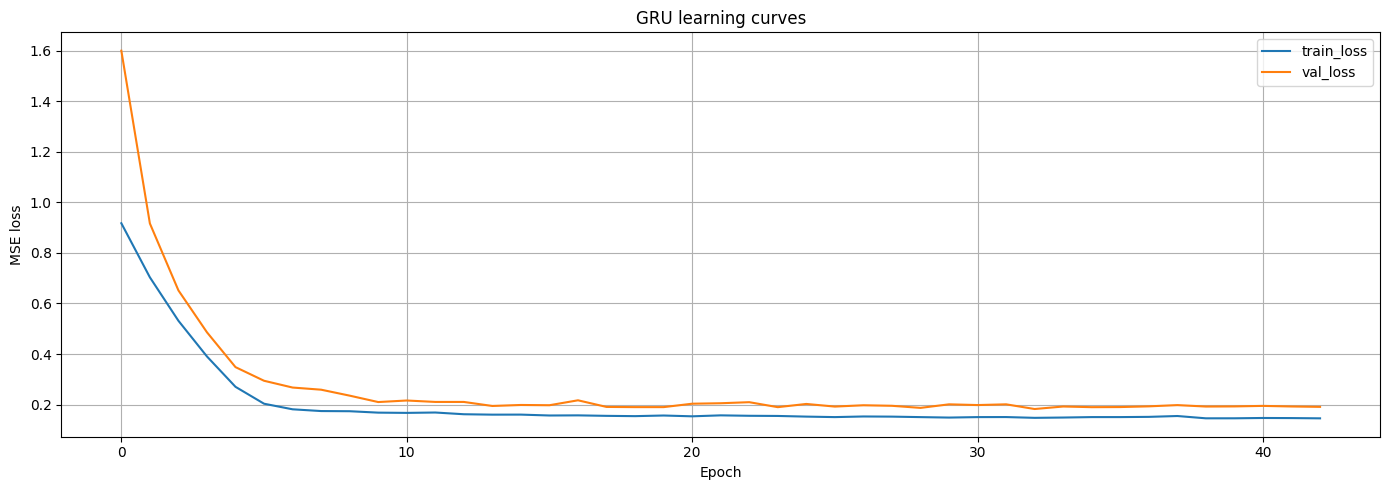

In [26]:
plt.figure()
plt.plot(history_gru["train_loss"], label="train_loss")
plt.plot(history_gru["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.title("GRU learning curves")
plt.tight_layout()
plt.savefig(FIG_DIR + "gru_learning_curves.png")
plt.show()

In [27]:
gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)
val_true = inverse_scale(gru_val_true_scaled, scaler)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)

gru_val_metrics = regression_metrics(val_true, gru_val_pred)
gru_val_metrics

{'MAE': 6.365323543548584,
 'RMSE': 7.914648849592351,
 'MAPE': 4.277391731739044}

## Выбор лучшей модели

In [28]:
models_val = pd.DataFrame(
    [
        {"model": "B1_naive",          **b1_val_metrics},
        {"model": "B2_moving_average", **b2_val_metrics},
        {"model": "B3_ridge",          **b3_val_metrics},
        {"model": "R1_gru",            **gru_val_metrics},
    ]
).sort_values("MAE").reset_index(drop=True)

display(models_val)

best_model_name = models_val.loc[0, "model"]
print("Best model on validation:", best_model_name)


,model,MAE,RMSE,MAPE
0,B3_ridge,5.362864,6.745034,3.567543
1,R1_gru,6.365324,7.914649,4.277392
2,B2_moving_average,12.655244,15.194095,8.818812
3,B1_naive,20.340093,24.364325,12.856044


Best model on validation: B3_ridge


In [29]:
b1_test_metrics, b2_test_metrics, b3_test_metrics, r1_test_metrics = None, None, None, None

In [30]:
gru_offset = len(test_df) - len(y_test_r)

if best_model_name == "B1_naive":
    best_test_pred  = naive_last(y_train_arr, y_test_arr)
    best_test_true  = y_test_arr
    best_test_dates = test_df["date"].reset_index(drop=True)
    best_test_metrics = regression_metrics(best_test_true, best_test_pred)
    b1_test_metrics = best_test_metrics

elif best_model_name == "B2_moving_average":
    best_test_pred = inverse_scale(moving_average_from_windows(X_test_r, window_ma=7), scaler)
    best_test_true = inverse_scale(y_test_r, scaler)
    best_test_dates = test_df["date"].iloc[gru_offset:].reset_index(drop=True)
    best_test_metrics = regression_metrics(best_test_true, best_test_pred)
    b2_test_metrics = best_test_metrics


elif best_model_name == "B3_ridge":
    best_test_pred  = ridge.predict(X_test_scaled)
    best_test_true  = y_test.values
    best_test_dates = test_feat["date"].reset_index(drop=True)
    best_test_metrics = regression_metrics(best_test_true, best_test_pred)
    b3_test_metrics = best_test_metrics


elif best_model_name == "R1_gru":
    gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)
    best_test_pred  = inverse_scale(gru_test_pred_scaled, scaler)
    best_test_true  = inverse_scale(gru_test_true_scaled, scaler)
    best_test_dates = test_df["date"].iloc[gru_offset:].reset_index(drop=True)
    best_test_metrics = regression_metrics(best_test_true, best_test_pred)
    r1_test_metrics = best_test_metrics


print(f"Test metrics for best model ({best_model_name}):", best_test_metrics)

Test metrics for best model (B3_ridge): {'MAE': 4.558187125691041, 'RMSE': 5.927031080225117, 'MAPE': 2.975718965878172}


## Сохранение артефактов

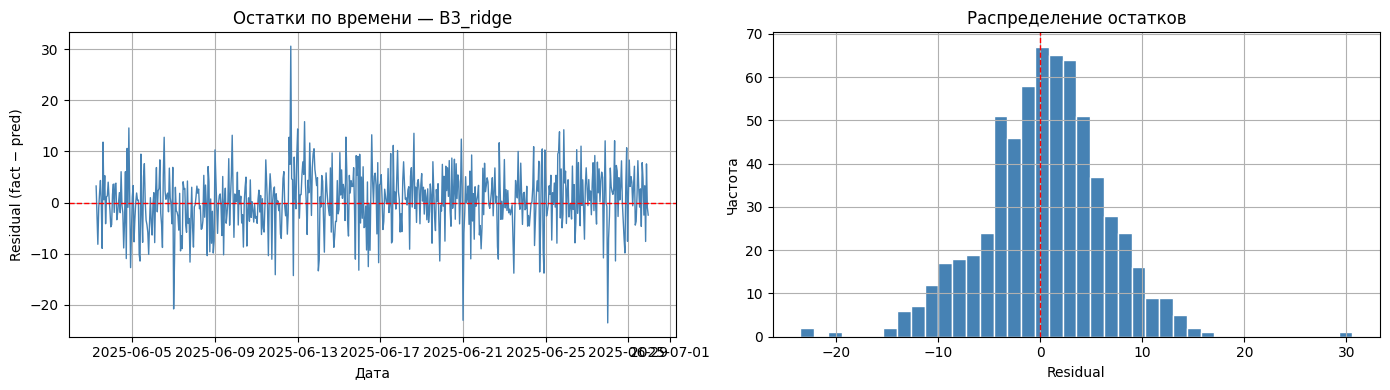

Среднее остатков: 0.4402
Std остатков:     5.9107


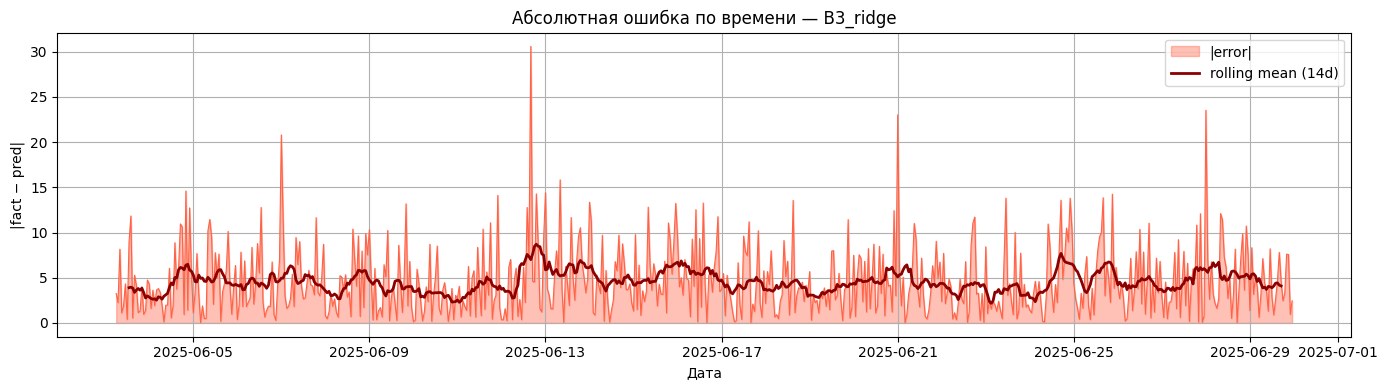

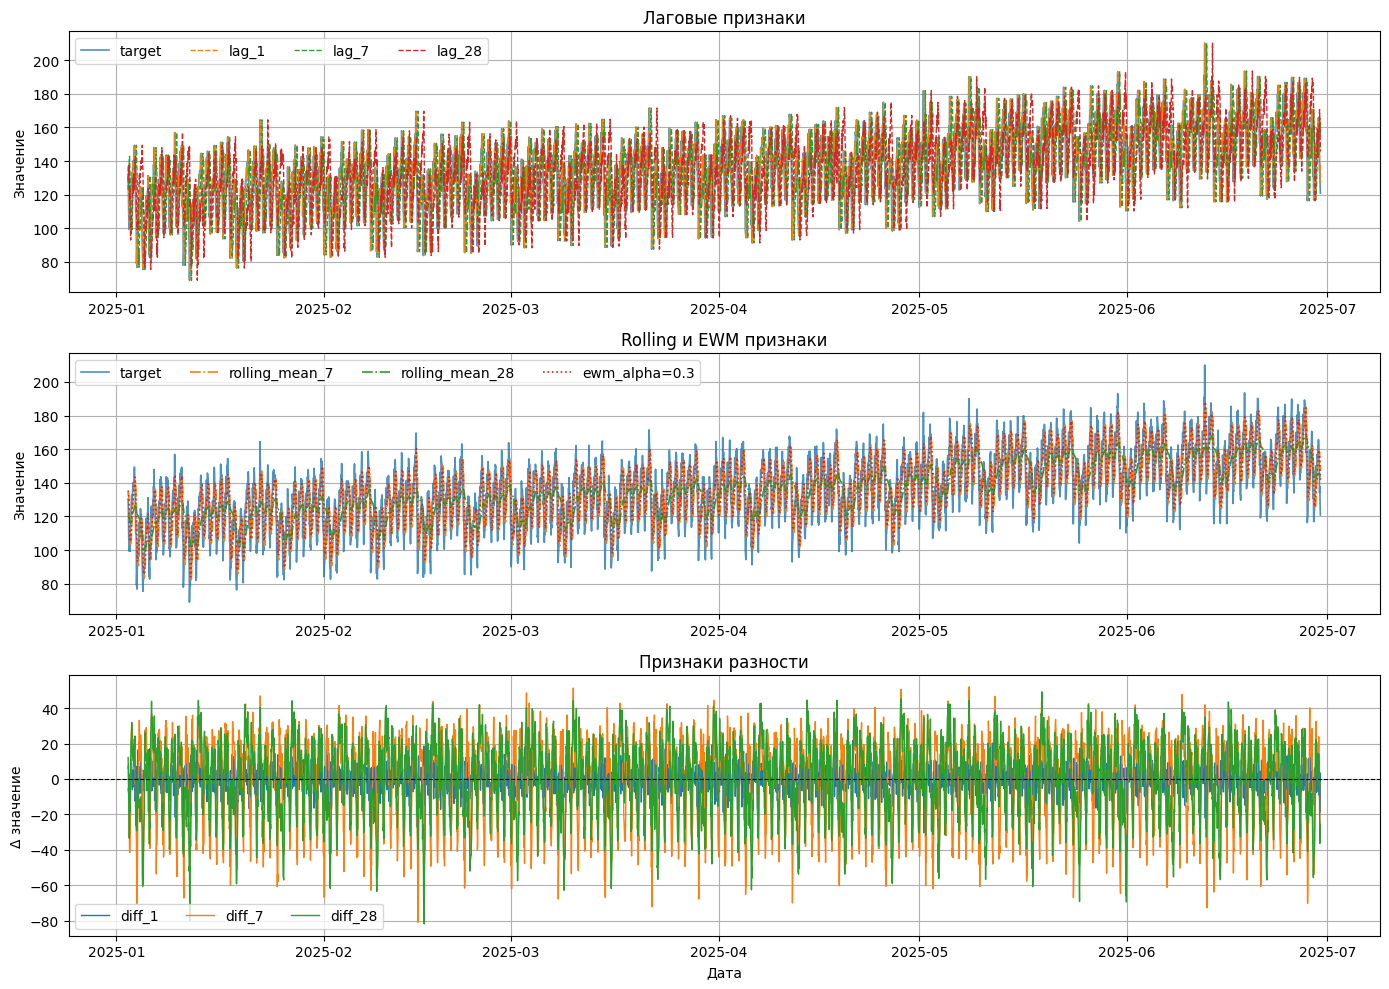

✅ Все три опциональных графика сохранены в artifacts/figures/


In [ ]:
residuals = best_test_true - best_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(best_test_dates, residuals, color="steelblue", linewidth=1.0)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.0)
axes[0].set_title(f"Остатки по времени — {best_model_name}")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Residual (fact − pred)")

axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.0)
axes[1].set_title("Распределение остатков")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Частота")

plt.tight_layout()
plt.savefig(FIG_DIR + "residuals_best.png", dpi=100)
plt.show()
print("Среднее остатков:", residuals.mean().round(4))
print("Std остатков:    ", residuals.std().round(4))

abs_errors = np.abs(residuals)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(best_test_dates, abs_errors, alpha=0.4, color="tomato", label="|error|")
ax.plot(best_test_dates, abs_errors, color="tomato", linewidth=0.8)

# Скользящее среднее ошибки для читаемости
window_err = min(14, len(abs_errors) // 4)
rolling_err = pd.Series(abs_errors).rolling(window_err, center=True).mean()
ax.plot(best_test_dates, rolling_err, color="darkred", linewidth=2.0,
        label=f"rolling mean ({window_err}d)")

ax.set_title(f"Абсолютная ошибка по времени — {best_model_name}")
ax.set_xlabel("Дата")
ax.set_ylabel("|fact − pred|")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + "error_by_time.png", dpi=100)
plt.show()


# %% Примеры признаков (feature_examples.png)
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

sample_dates = features_df["date"]

# 1. Лаги
axes[0].plot(sample_dates, features_df["target"],  label="target",       linewidth=1.2, alpha=0.8)
axes[0].plot(sample_dates, features_df["lag_1"],   label="lag_1",        linewidth=1.0, linestyle="--")
axes[0].plot(sample_dates, features_df["lag_7"],   label="lag_7",        linewidth=1.0, linestyle="--")
axes[0].plot(sample_dates, features_df["lag_28"],  label="lag_28",       linewidth=1.0, linestyle="--")
axes[0].set_title("Лаговые признаки")
axes[0].set_ylabel("Значение")
axes[0].legend(ncol=4)

# 2. Rolling-средние
axes[1].plot(sample_dates, features_df["target"],           label="target",         linewidth=1.2, alpha=0.8)
axes[1].plot(sample_dates, features_df["rolling_mean_7"],   label="rolling_mean_7", linewidth=1.2, linestyle="-.")
axes[1].plot(sample_dates, features_df["rolling_mean_28"],  label="rolling_mean_28",linewidth=1.2, linestyle="-.")
axes[1].plot(sample_dates, features_df["ewm_3"],            label="ewm_alpha=0.3",  linewidth=1.2, linestyle=":")
axes[1].set_title("Rolling и EWM признаки")
axes[1].set_ylabel("Значение")
axes[1].legend(ncol=4)

# 3. Разности
axes[2].plot(sample_dates, features_df["diff_1"],  label="diff_1",  linewidth=1.0)
axes[2].plot(sample_dates, features_df["diff_7"],  label="diff_7",  linewidth=1.0)
axes[2].plot(sample_dates, features_df["diff_28"], label="diff_28", linewidth=1.0)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title("Признаки разности")
axes[2].set_xlabel("Дата")
axes[2].set_ylabel("Δ значение")
axes[2].legend(ncol=3)

plt.tight_layout()
plt.savefig(FIG_DIR + "feature_examples.png", dpi=100)
plt.show()

print("Все три опциональных графика сохранены в", FIG_DIR)


In [31]:
def make_run_row(
    experiment_id: str,
    val_metrics: dict,
    test_metrics: dict | None,
    task: str = "forecasting",
    dataset: str = "S12-hw-dataset",
    seed: int = 42,
    split_summary: str = "0.7/0.15/0.15 by time",
    window_size=None,
    horizon: int = 1,
    model_summary: str = "",
    features_summary: str = "",
    scaler: str = "",
    optimizer: str = "",
    lr=None,
    epochs_trained=None,
    notes: str = "",
):
    return {
        "experiment_id": experiment_id,
        "task": task,
        "dataset": dataset,
        "seed": seed,
        "split_summary": split_summary,
        "window_size": window_size,
        "horizon": horizon,
        "model_summary": model_summary,
        "features_summary": features_summary,
        "scaler": scaler,
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs_trained,
        "best_val_mae": val_metrics["MAE"],
        "best_val_rmse": val_metrics["RMSE"],
        "best_val_mape": val_metrics["MAPE"],
        "test_mae":  None if test_metrics is None else test_metrics["MAE"],
        "test_rmse": None if test_metrics is None else test_metrics["RMSE"],
        "test_mape": None if test_metrics is None else test_metrics["MAPE"],
        "notes": notes,
    }

In [34]:
best_gru_path = ART_DIR + "best_gru.pt"
torch.save(gru_model.state_dict(), best_gru_path)

best_gru_config = {
    "window_size": window_size,
    "hidden_size": hidden_size,
    "num_layers": num_layers,
    'dropout' : dropout,
    "batch_size": batch_size,
    "lr": lr,
    "epochs": MAX_EPOCHS,
    "seed": 42,
    "scaler": "StandardScaler(target)",
}
import json
with open(ART_DIR + "best_gru_config.json", "w") as f:
    json.dump(best_gru_config, f, indent=2)

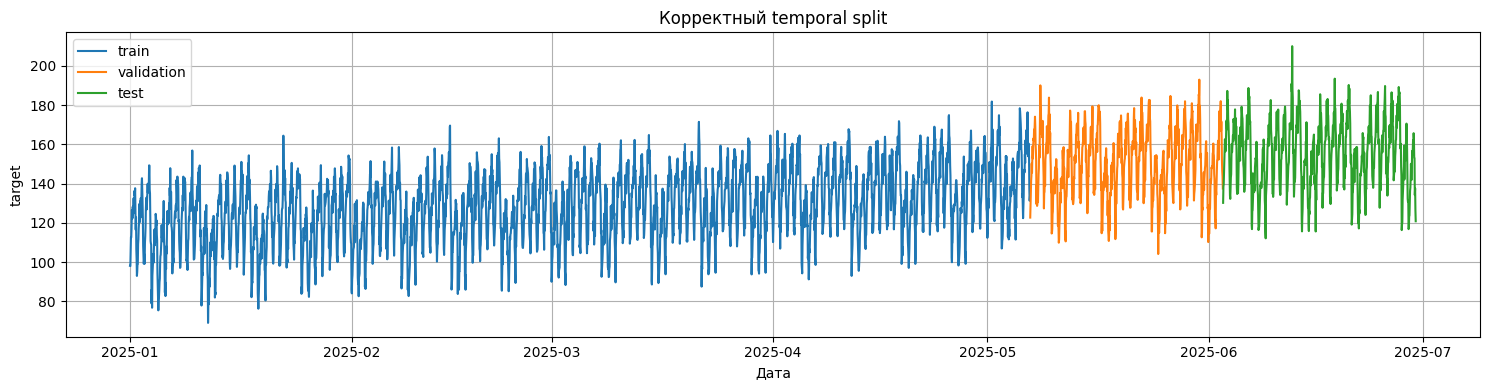

In [35]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректный temporal split")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + "series_split.png")
plt.show()

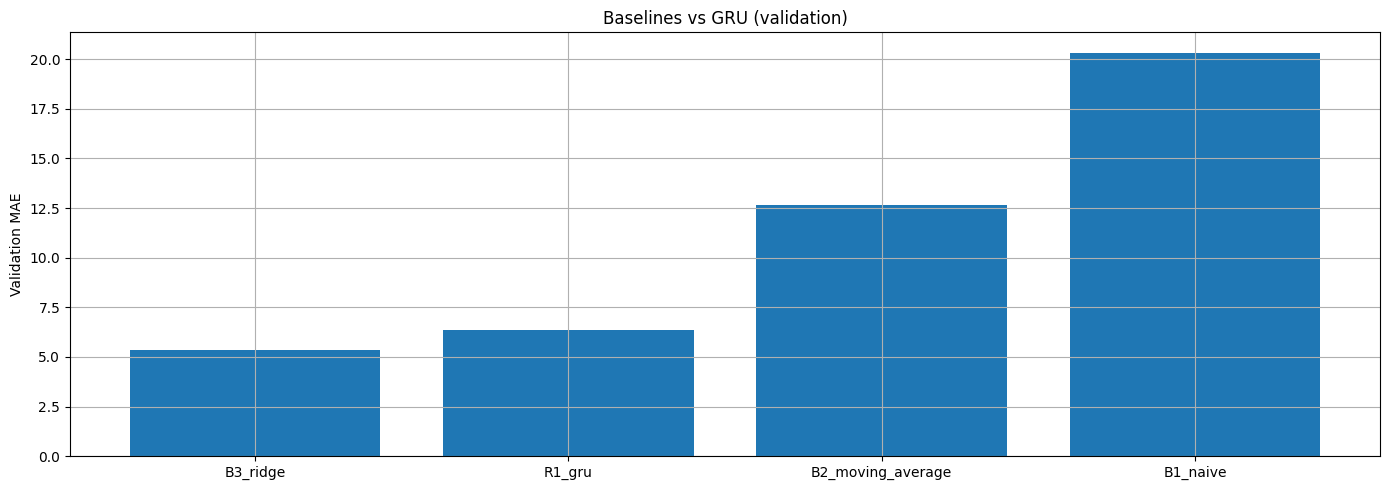

In [36]:
plt.figure()
plt.bar(models_val["model"], models_val["MAE"])
plt.ylabel("Validation MAE")
plt.title("Baselines vs GRU (validation)")
plt.tight_layout()
plt.savefig(FIG_DIR + "baselines_compare.png")
plt.show()

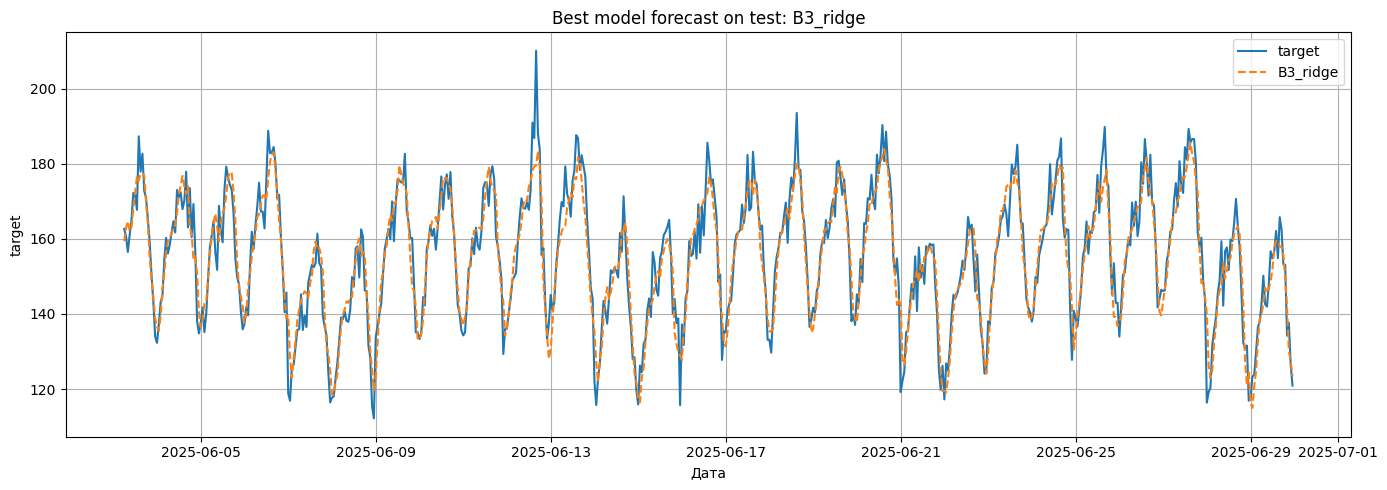

In [37]:
plt.figure(figsize=(14, 5))
plt.plot(best_test_dates, best_test_true, label="target",              linewidth=1.5)
plt.plot(best_test_dates, best_test_pred, label=f"{best_model_name}",  linewidth=1.5, linestyle="--")
plt.title(f"Best model forecast on test: {best_model_name}")
plt.xlabel("Дата")
plt.ylabel("target")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + "best_forecast_test.png")
plt.show()


In [38]:

rows = []

rows.append(
    make_run_row(
        experiment_id="B1",
        val_metrics=b1_val_metrics,
        test_metrics=b1_test_metrics,
        model_summary="naive_last",
        features_summary="no features",
        scaler="none",
    )
)

rows.append(
    make_run_row(
        experiment_id="B2",
        val_metrics=b2_val_metrics,
        test_metrics=b2_test_metrics,
        model_summary="moving_average(window=7)",
        features_summary="no features",
        scaler="none",
    )
)

rows.append(
    make_run_row(
        experiment_id="B3",
        val_metrics=b3_val_metrics,
        test_metrics=b3_test_metrics,
        model_summary="Ridge(alpha=1.0)",
        features_summary="lags + rolling + calendar",
        scaler="StandardScaler(features)",
    )
)

rows.append(
    make_run_row(
        experiment_id="R1",
        val_metrics=gru_val_metrics,
        test_metrics=r1_test_metrics,
        window_size=window_size,
        model_summary=f"GRU(hidden_size={hidden_size}, num_layers={num_layers})",
        features_summary="scaled target windows",
        scaler="StandardScaler(target)",
        optimizer="Adam",
        lr=lr,
        epochs_trained=len(history_gru["train_loss"]),
        notes="best GRU on validation",
    )
)
runs_df = pd.DataFrame(rows)
runs_df.to_csv(ART_DIR + "runs.csv", index=False)
runs_df

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset,42,0.7/0.15/0.15 by time,NaN,1,naive_last,no features,none,,NaN,NaN,20.340093,24.364325,12.856044,NaN,NaN,NaN,
1,B2,forecasting,S12-hw-dataset,42,0.7/0.15/0.15 by time,NaN,1,moving_average(window=7),no features,none,,NaN,NaN,12.655244,15.194095,8.818812,NaN,NaN,NaN,
2,B3,forecasting,S12-hw-dataset,42,0.7/0.15/0.15 by time,NaN,1,Ridge(alpha=1.0),lags + rolling + calendar,StandardScaler(features),,NaN,NaN,5.362864,6.745034,3.567543,4.558187,5.927031,2.975719,
3,R1,forecasting,S12-hw-dataset,42,0.7/0.15/0.15 by time,56.0,1,"GRU(hidden_size=64, num_layers=2)",scaled target windows,StandardScaler(target),Adam,0.001,43.0,6.365324,7.914649,4.277392,NaN,NaN,NaN,best GRU on validation
